In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Đọc file dữ liệu sạch đã qua xử lý từ Phần 2
df = pd.read_csv('credit_card_prepared.csv')

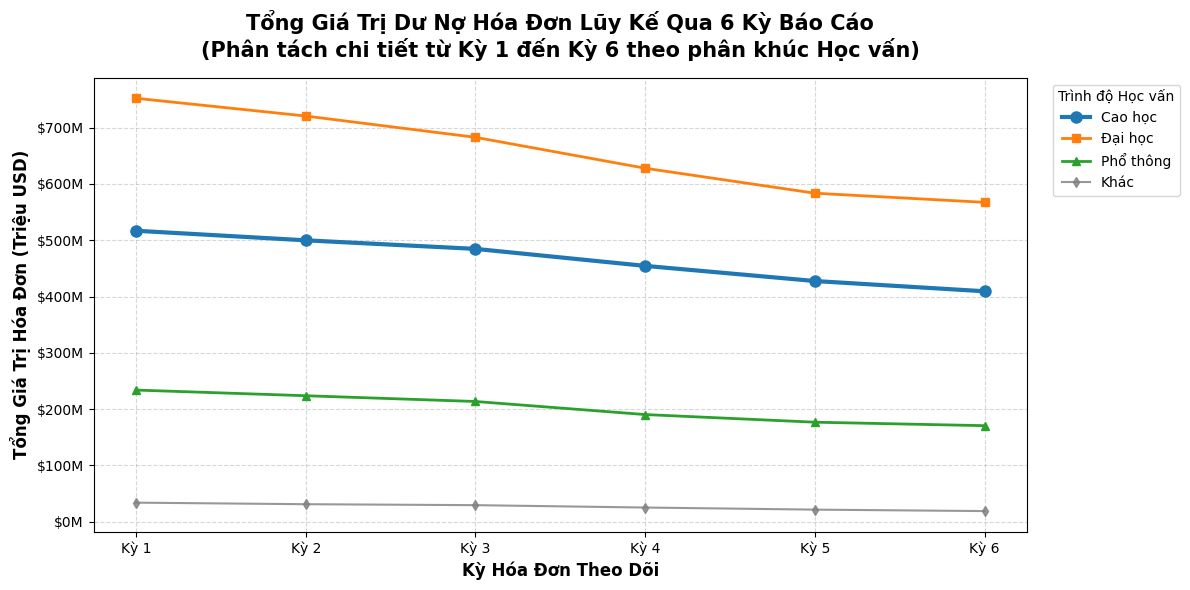

In [13]:
# Sắp xếp lại danh sách theo đúng thứ tự thời gian từ Kỳ 1 đến Kỳ 6
periods = ['Kỳ 1', 'Kỳ 2', 'Kỳ 3', 'Kỳ 4', 'Kỳ 5', 'Kỳ 6']
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']

# Gom nhóm tính tổng số dư nợ hóa đơn theo đúng thứ tự vừa sắp xếp
grouped_bill = df.groupby('Education_Level')[bill_cols].sum()

plt.figure(figsize=(12, 6))

# Vẽ từng đường cho mỗi nhóm học vấn với marker khác nhau giống mẫu
plt.plot(periods, grouped_bill.loc['Graduate_School', :] / 1e6, marker='o', linewidth=3, markersize=8, color='#1f77b4', label='Cao học')
plt.plot(periods, grouped_bill.loc['University', :] / 1e6, marker='s', linewidth=2, markersize=6, color='#ff7f0e', label='Đại học')
plt.plot(periods, grouped_bill.loc['High_School', :] / 1e6, marker='^', linewidth=2, markersize=6, color='#2ca02c', label='Phổ thông')
plt.plot(periods, grouped_bill.loc['Others', :] / 1e6, marker='d', linewidth=1.5, markersize=5, color='#7f7f7f', alpha=0.8, label='Khác')

plt.title('Tổng Giá Trị Dư Nợ Hóa Đơn Lũy Kế Qua 6 Kỳ Báo Cáo\n(Phân tách chi tiết từ Kỳ 1 đến Kỳ 6 theo phân khúc Học vấn)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('Kỳ Hóa Đơn Theo Dõi', fontsize=12, fontweight='bold')
plt.ylabel('Tổng Giá Trị Hóa Đơn (Triệu USD)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

# Định dạng nhãn trục Y thành dạng tiền tệ triệu đô ($X.0M) giống mẫu $X.0B
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${x:,.0f}M'))

# Đẩy hộp chú thích ra rìa ngoài bên phải
plt.legend(title='Trình độ Học vấn', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

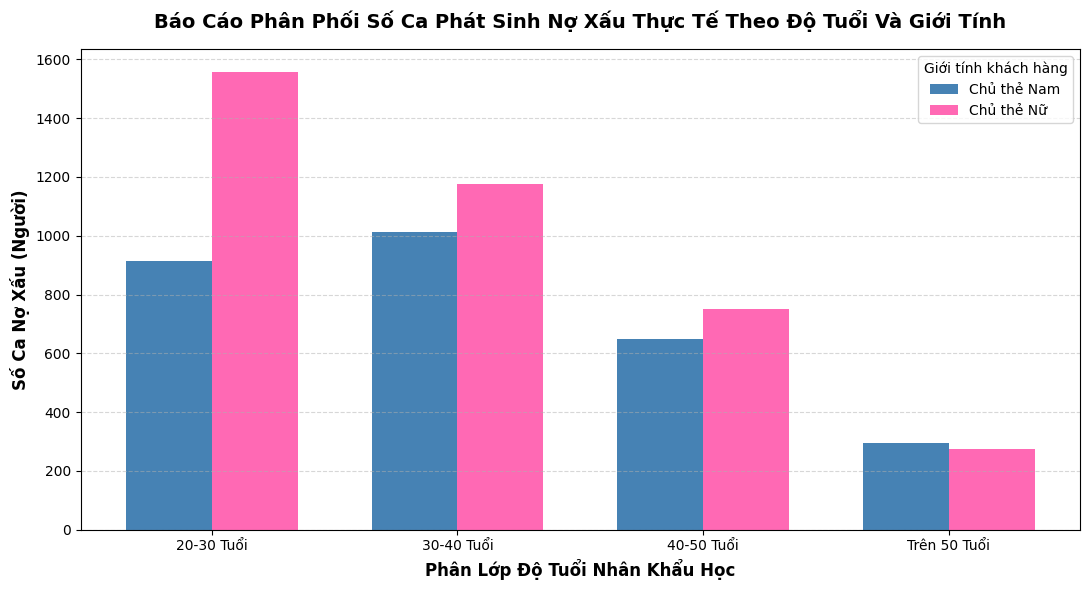

In [11]:

# Phân lớp tuổi
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 70], labels=['20-30 Tuổi', '30-40 Tuổi', '40-50 Tuổi', 'Trên 50 Tuổi'])

# Lọc ra nhóm nợ xấu và đếm phân phối chéo
pivot_bar = df[df['default_payment_next_month'] == 1].pivot_table(
    index='AGE_GROUP', columns='SEX', values='default_payment_next_month', aggfunc='count', fill_value=0
)

x = np.arange(len(pivot_bar.index))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

# Vẽ 2 cột nằm cạnh nhau cho từng nhóm tuổi
rects1 = ax.bar(x - width/2, pivot_bar[1], width, label='Chủ thẻ Nam', color='#4682B4')
rects2 = ax.bar(x + width/2, pivot_bar[2], width, label='Chủ thẻ Nữ', color='#FF69B4')

ax.set_title('Báo Cáo Phân Phối Số Ca Phát Sinh Nợ Xấu Thực Tế Theo Độ Tuổi Và Giới Tính', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Phân Lớp Độ Tuổi Nhân Khẩu Học', fontsize=12, fontweight='bold')
ax.set_ylabel('Số Ca Nợ Xấu (Người)', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot_bar.index)
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(title='Giới tính khách hàng', loc='upper right')

plt.tight_layout()
plt.show()

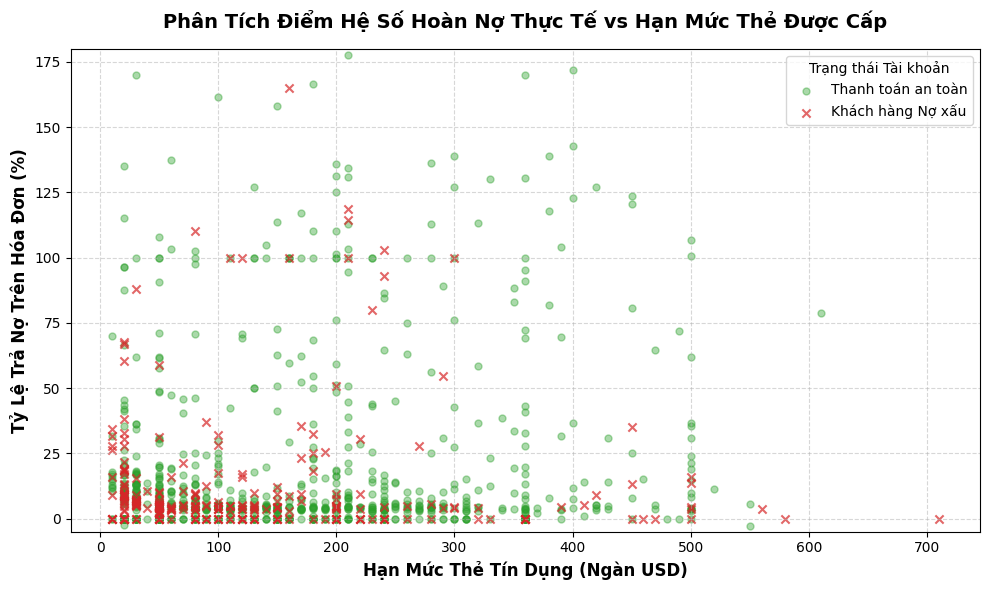

In [10]:


plt.figure(figsize=(10, 6))

# Lấy mẫu ngẫu nhiên 1200 điểm để biểu đồ thoáng, dễ nhìn hành vi phân bố
sample_df = df.sample(n=1200, random_state=42)

good_pay = sample_df[sample_df['default_payment_next_month'] == 0]
bad_pay = sample_df[sample_df['default_payment_next_month'] == 1]

# Vẽ nhóm tốt bằng dấu chấm tròn màu xanh, nhóm nợ xấu bằng dấu X màu đỏ
plt.scatter(good_pay['LIMIT_BAL'] / 1000, good_pay['Pay_To_Bill_Ratio'] * 100, color='#2ca02c', alpha=0.4, label='Thanh toán an toàn', s=25)
plt.scatter(bad_pay['LIMIT_BAL'] / 1000, bad_pay['Pay_To_Bill_Ratio'] * 100, color='#d62728', alpha=0.7, label='Khách hàng Nợ xấu', s=35, marker='x')

plt.title('Phân Tích Điểm Hệ Số Hoàn Nợ Thực Tế vs Hạn Mức Thẻ Được Cấp', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hạn Mức Thẻ Tín Dụng (Ngàn USD)', fontsize=12, fontweight='bold')
plt.ylabel('Tỷ Lệ Trả Nợ Trên Hóa Đơn (%)', fontsize=12, fontweight='bold')
plt.ylim(-5, 180) # Khống chế khoảng hiển thị tránh điểm nhiễu ngoại lai
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Trạng thái Tài khoản')

plt.tight_layout()
plt.show()

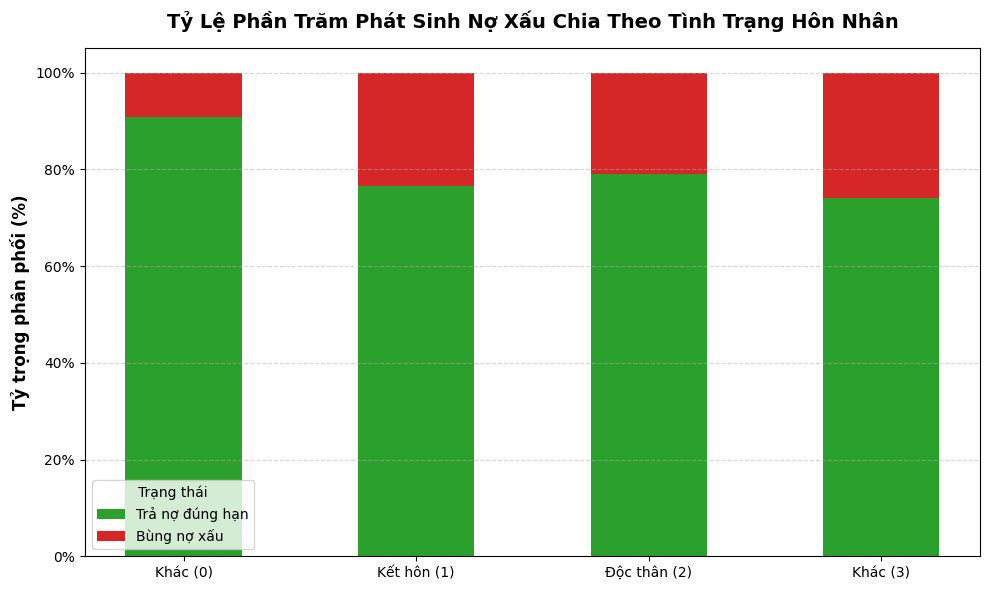

In [7]:

df = pd.read_csv('credit_card_prepared.csv')

# Tính toán tỷ lệ phần trăm phân phối nợ xấu theo nhóm Hôn nhân
pivot_marriage = df.pivot_table(
    index='MARRIAGE', columns='default_payment_next_month', values='LIMIT_BAL', aggfunc='count', fill_value=0
)
pivot_marriage_pct = pivot_marriage.div(pivot_marriage.sum(axis=1), axis=0) * 100

plt.figure(figsize=(10, 6))
labels = ['Kết hôn', 'Độc thân', 'Khác']

# Tạo cột chồng bằng biến bottom
labels = ['Khác (0)', 'Kết hôn (1)', 'Độc thân (2)', 'Khác (3)']
plt.bar(labels, pivot_marriage_pct[0], width=0.5, label='Trả nợ đúng hạn', color='#2ca02c')
plt.bar(labels, pivot_marriage_pct[1], bottom=pivot_marriage_pct[0], width=0.5, label='Bùng nợ xấu', color='#d62728')

plt.title('Tỷ Lệ Phần Trăm Phát Sinh Nợ Xấu Chia Theo Tình Trạng Hôn Nhân', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Tỷ trọng phân phối (%)', fontsize=12, fontweight='bold')

# Định dạng nhãn trục Y hiển thị ký hiệu % mẫu mực
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'{x:.0f}%'))
plt.legend(title='Trạng thái', loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

C:\Users\MTBH\AppData\Local\Temp\ipykernel_23888\1686584540.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data_box, patch_artist=True, labels=['Trả đúng hạn', 'Nợ xấu'], widths=0.4)


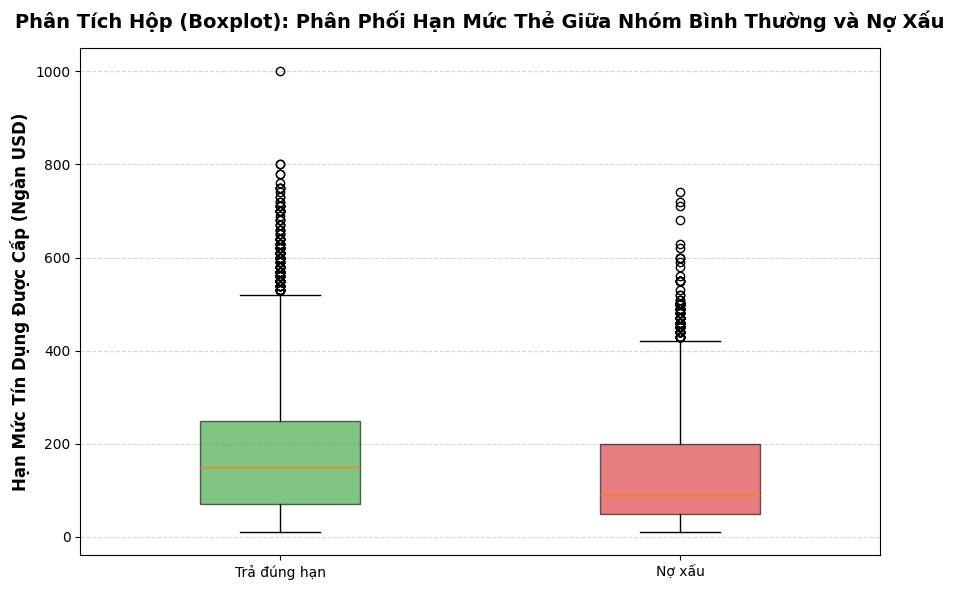

In [9]:

# Chia dữ liệu hạn mức thành 2 mảng tương ứng với 2 trạng thái tài khoản
data_box = [
    df[df['default_payment_next_month'] == 0]['LIMIT_BAL'] / 1000,
    df[df['default_payment_next_month'] == 1]['LIMIT_BAL'] / 1000
]

plt.figure(figsize=(9, 6))
box = plt.boxplot(data_box, patch_artist=True, labels=['Trả đúng hạn', 'Nợ xấu'], widths=0.4)

# Tô màu sắc cho các khối hộp
colors = ['#2ca02c', '#d62728']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6) # Chỉnh độ trong suốt cho màu dịu đi giống mẫu

plt.title('Phân Tích Hộp (Boxplot): Phân Phối Hạn Mức Thẻ Giữa Nhóm Bình Thường và Nợ Xấu', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Hạn Mức Tín Dụng Được Cấp (Ngàn USD)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()